In [ ]:
# Data Reduction - Attribute Subset Selection
#
# In this lab, we'll be learning about different techniques that are generally
# used to select the best subset of attributes for a given model/algorith
#
# Attribute selection is the process of selection of attributes for the purpose
# of your analysis.
#
# Different variables can have different impact at the output of your analysis
# or impact the performance of your model/algorithm overall, which makes it
# important to choose the right attributes.
#
# There are multiple methods through which we can choose the right attributes:
#
# a. Forward Selection
# b. Backward Selection
# c. Decision Tree Induction
#
# We have primarily done this for Linear Regression and Random Forest model

In [1]:
# Download the dataset file to local storage to current directory (from publicly
# shared drive file)
#
# Original source:
# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
!gdown 1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP

Downloading...
From: https://drive.google.com/uc?id=1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
To: /content/housing.csv
100% 461k/461k [00:00<00:00, 60.3MB/s]


In [2]:
# Import required libraries
import pandas as pd

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [3]:
# Load the dataset file into memory
DATASET_PATH = r'https://raw.githubusercontent.com/2025em1100422-ui/kaggledatset/564eb719455f768c2a008bc893dab1f6eb1e8b98/train.csv'
df = pd.read_csv(DATASET_PATH)
df


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
# Tuple Reduction: Reduces the number of data instances using techniques such as
# sampling and clustering

# Dimensionality Reduction will be covered in the next lab 6.2

# Data Cube Aggregation:
# Summarizes data by aggregating values at different levels (e.g., daily to
# monthly sales).

# Data Compression:
# Uses encoding methods (e.g., wavelet transforms, run-length encoding) to
# reduce data size.

In [ ]:
# We'll be considering a scenario where we want to figure out the best
# attributes to predict the SalePrice of a house

In [4]:
model = LinearRegression()

target_variable = "SalePrice"

# Pre-processing the dataset
df_processed = df.fillna(0)

X = df_processed.drop(target_variable, axis=1).select_dtypes(include='number')
Y = df_processed[target_variable]

model.fit(X, Y)

LinearRegression()

# New Section

In [ ]:
# 1. Forward Selection
#
# In forward selection, we start with a minimal set and then include more
# attributes one by one as we find them positively impactful for the analysis
# being performed.
#
# We'll be sklearn's SequentialFeatureSelector to achieve the same

In [5]:
# We'll be using SequentialFeatureSelector with direction='backward'
#
# n_features_to_select determines the number of features that the model selects
# In our case this value is set to 5
#
# direction='backward' mentioned that we would be considering all the features
# first and then removing them as per their importance
#
# cv parameter refers to the total number of folds for cross-validation
#
# n_jobs refers to the number of jobs to be used and "n_jobs=-1" specifically
# implies that the maximum number of jobs can be used
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward', cv=5, n_jobs=-1)
sfs.fit(X, Y)

# Get the names of the selected features
selected_indices = sfs.get_support(indices=True)
selected_features_wrapper = df.columns[selected_indices]

print("\nSelected features (Wrapper Method - Forward Elimination):")
print(selected_features_wrapper)

# The methods selected for


Selected features (Wrapper Method - Forward Elimination):
Index(['MSSubClass', 'LotArea', 'Utilities', 'HouseStyle', 'MasVnrArea'], dtype='object')


In [ ]:
# 2. Backward Selection
#
# In backward selection, we start the complete set and exclude one attribute
# at a time, until we have the desired/right number of attributes.

In [6]:
# We'll be using SequentialFeatureSelector to achieve this with a backward
# direction
#
# n_features_to_select determines the number of features that the model selects
#
# direction='backward' mentioned that we would be considering all the features
# first and then removing them as per their importance
#
# cv parameter refers to the total number of folds for cross-validation
#
# n_jobs refers to the number of jobs to be used and "n_jobs=-1" specifically
# implies that the maximum number of jobs can be used
sfs = SequentialFeatureSelector(model, n_features_to_select=5,
                                direction='backward', cv=5, n_jobs=-1)
sfs.fit(X, Y)

# Get the names of the selected features
selected_indices = sfs.get_support(indices=True)
selected_features_wrapper = df.columns[selected_indices]

print("\nSelected features (Wrapper Method - Backward Elimination):")
print(selected_features_wrapper)

# All the features were first considered and then based on their feature
# importance calculated by the model were


Selected features (Wrapper Method - Backward Elimination):
Index(['MSSubClass', 'LotArea', 'Alley', 'HouseStyle', 'OverallQual'], dtype='object')


In [ ]:
# 3. Decision Tree Induction
#
# Decision Trees can be used for feature selection by examining the importance
# of each feature in the tree building process. Features that appear higher in
# the tree or are used more frequently in splitting decisions are considered
# more important.
#
# We can access feature importance scores from a trained Decision Tree model
# to rank and select features.


Feature importances from Decision Tree:


,0
OverallQual,0.640979
GrLivArea,0.101922
2ndFlrSF,0.041758
TotalBsmtSF,0.033788
1stFlrSF,0.025740
GarageCars,0.023287
BsmtFinSF1,0.022791
YearBuilt,0.018737
GarageArea,0.013240
GarageYrBlt,0.010260


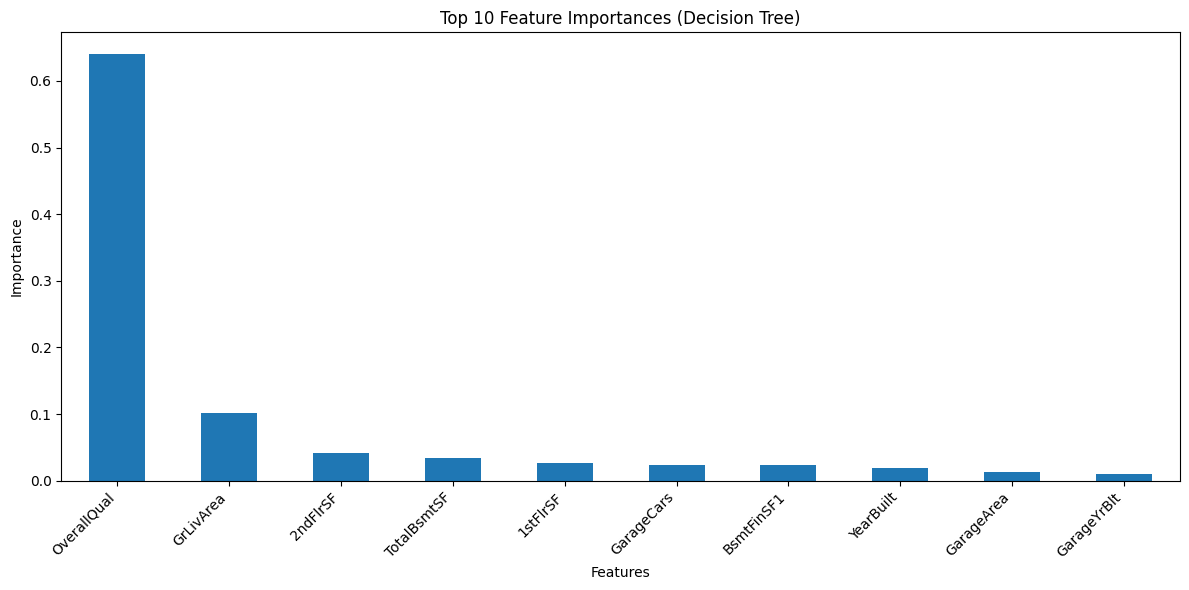

In [7]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Initialize and train a Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X, Y)

# Get feature importances
feature_importances = dt_model.feature_importances_

# Create a pandas Series for easier visualization
importance_series = pd.Series(feature_importances, index=X.columns)

# Sort feature importances and display the top ones
top_features = importance_series.sort_values(ascending=False)

print("\nFeature importances from Decision Tree:")
display(top_features)

#  Visualize feature importances
plt.figure(figsize=(12, 6))
top_features.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()